In [2]:
import json
import os
import numpy as np

filename = os.getcwd().split('/')[:-1]
filename = '/'.join(filename) + '/dataset/sysid_data.json'

with open(filename, 'r') as f:
    data = json.load(f)

In [ ]:
from scipy.signal import savgol_filter

def compute_velocities(rollout):
    times = np.array(rollout['times'])
    states = np.array(rollout['measured_states'])[:, :10]
    times = times[1:] - times[:-1]
    v1 = (states[1:] - states[:-1]) / times[:, None]
    dt = np.mean(times)
    v2 = savgol_filter(states, window_length=11, polyorder=3, deriv=1, delta=dt, axis=0)
    return v1, v2

In [35]:
rollout = data['data'][0]
motor_idx = rollout['motor_idx']

v1, v2 = compute_velocities(rollout)

print(v1.shape, v2.shape)


(149, 10) (150, 10)


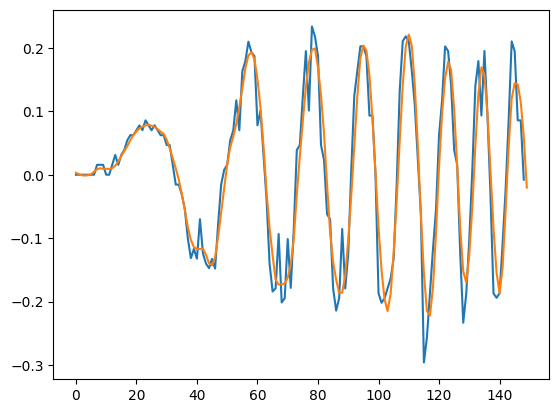

In [34]:
import matplotlib.pyplot as plt

plt.plot(v1[:, motor_idx])
plt.plot(v2[:, motor_idx])